In [9]:
import pandas as pd
import nibabel as nib
from glob import glob
import numpy as np
import statsmodels.api as sp
#imported the full paths since it wasn't working otherwise - not sure why 
from scipy.stats import pearsonr
from statsmodels.stats.weightstats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.tsa.stattools import pacf
#from pingouin import partial_corr

In [30]:
# read in df_tabular with regional and network based data 

df_tabular = pd.read_csv('../resources/merged_tabular_withconn_flipped.tsv',sep='\t')

In [31]:
df_lobe = df_tabular[df_tabular["dataset"] == "LOBE"]
df_HCP = df_tabular[df_tabular["dataset"] == "HCP"]

In [32]:
# Step 2: Identify RSFC columns (columns that start with "RSFC_")
rsfc_columns = [col for col in df_lobe.columns if col.startswith('RSFC_')]
rsc_columns = [col for col in df_lobe.columns if col.startswith('RSC_')]
rfc_columns = [col for col in df_lobe.columns if col.startswith('RFC_')]


In [51]:
# Step 3: Compute Pearson correlations between each RSFC column and 'asm_first_scan'
correlation_results = []
nan_issues = []  # Store columns with NaNs

for col in rsfc_columns:
    if col in df_lobe.columns:
        # Check for NaNs
        nan_count_col = df_lobe[col].isna().sum()
        nan_count_asm = df_lobe['asm_first_scan'].isna().sum()
        
        if nan_count_col > 0 or nan_count_asm > 0:
            nan_issues.append((col, nan_count_col, nan_count_asm))
            continue  # Skip correlation if NaNs are present
        
        # Compute correlation
        r, p = pearsonr(df_lobe[col], df_lobe['asm_first_scan'])
        correlation_results.append((col, r, p))

# Convert results to DataFrame
correlation_df = pd.DataFrame(correlation_results, columns=['RSFC_column', 'correlation', 'p_value'])

# Step 4: Apply FDR correction
if not correlation_df.empty:
    rejected, corrected_p_values = fdrcorrection(correlation_df['p_value'], alpha=0.05, method='indep')
    correlation_df['fdr_corrected_p'] = corrected_p_values
    correlation_df['significant'] = rejected  # Boolean: True if FDR-corrected p < 0.05

# Step 5: Display results
print("\n📝 Correlation Results:")
print(correlation_df.sort_values(by='p_value'))

# Step 6: Report columns with NaNs
if nan_issues:
    print("\n⚠️ The following columns had NaNs and were skipped:")
    for col, nan_rsfc, nan_asm in nan_issues:
        print(f"   - {col}: {nan_rsfc} missing in RSFC, {nan_asm} missing in asm_first_scan")

# Filter for significant results
significant_df = correlation_df[correlation_df['significant'] == True]

# Save to a CSV file (optional)
#significant_df.to_csv("../results/significant_correlations.csv", index=False)

# Display the filtered DataFrame

print(significant_df)


📝 Correlation Results:
                       RSFC_column  correlation   p_value  fdr_corrected_p  \
4            RSFC_ipsi_A9l_Default    -0.743189  0.000113         0.027880   
155  RSFC_contra_A1-2-3ulhf_SomMot    -0.642705  0.001677         0.206290   
37   RSFC_contra_A44op_SalVentAttn     0.614583  0.003032         0.248634   
235       RSFC_contra_Stha_Subcort    -0.587696  0.005085         0.250913   
242        RSFC_ipsi_cTtha_Subcort     0.583266  0.005514         0.250913   
..                             ...          ...       ...              ...   
91     RSFC_contra_A37elv_DorsAttn     0.005622  0.980705         0.995626   
136           RSFC_ipsi_A39rd_Cont     0.004812  0.983484         0.995626   
152          RSFC_ipsi_A31_Default    -0.001633  0.994396         0.996873   
125       RSFC_contra_A7r_DorsAttn    -0.001211  0.995844         0.996873   
175       RSFC_contra_A23d_Default    -0.000911  0.996873         0.996873   

     significant  
4           True  
1

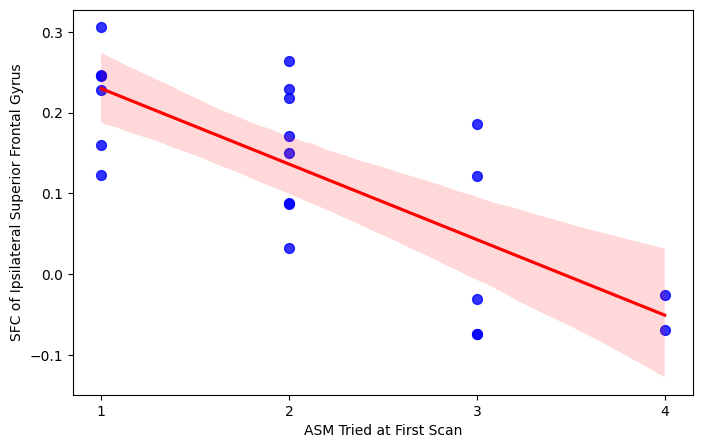

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter dataset for LOBE
df_lobe = df_tabular[df_tabular['dataset'] == 'LOBE']

# Scatter plot with regression line
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df_lobe['asm_first_scan'], 
    y=df_lobe['RSFC_ipsi_A9l_Default'], 
    scatter=True, 
    line_kws={"color": "red"},  # Regression line in red
    scatter_kws={"color": "blue", "s": 50}  # Blue dots, size 50
)

# Ensure x-axis is only whole numbers
xmin, xmax = df_lobe['asm_first_scan'].min(), df_lobe['asm_first_scan'].max()
plt.xticks(np.arange(int(xmin), int(xmax) + 1, step=1))  # Set whole number ticks

# Labels & Title
plt.xlabel("ASM Tried at First Scan")
plt.ylabel("SFC of Ipsilateral Superior Frontal Gyrus")


# Show Plot
plt.show()
